# 03 - Agréger et lire les flux environnementaux

Une empreinte nationale donne un total, mais pas immédiatement son origine géographique. Ce notebook construit une matrice reliant le lieu où les pressions ont lieu au lieu où se trouve la demande finale.

À la fin, vous saurez :

- construire une concordance géographique explicite ;
- agréger une matrice sans perdre son total ;
- lire les lignes, les colonnes et la diagonale d’une matrice origine-destination ;
- distinguer les pressions internes à une région des pressions provenant de l’extérieur ;
- expliquer ce que l’agrégation rend plus lisible et ce qu’elle masque.

## 1. La question étudiée

Pour chaque région consommatrice, nous voulons localiser les émissions climatiques dans les régions productrices. La cellule $(i,j)$ de la matrice répondra à la question suivante :

> Combien d’émissions ont lieu dans la région $i$ pour satisfaire la demande finale de la région $j$ ?

La somme d’une colonne est donc une empreinte de consommation. La somme d’une ligne correspond aux émissions d’un territoire attribuables à toutes les demandes finales du monde.

## 2. Charger EXIOBASE et préparer l’indicateur climatique

Le calcul reprend le périmètre climatique du notebook `02`. Seule l’extension `air_emissions` est calculée. Pour les colonnes dont la production monétaire est nulle, l’intensité est fixée à zéro selon la convention déjà documentée dans le notebook précédent.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import pymrio as mr

ANNEE = 2022
DOSSIER_EXIOBASE = Path("D:/EXIOBASE/3.10.2")
ARCHIVE_EXIOBASE = DOSSIER_EXIOBASE / f"IOT_{ANNEE}_ixi.zip"

if not ARCHIVE_EXIOBASE.exists():
    raise FileNotFoundError(
        f"Archive absente : {ARCHIVE_EXIOBASE}. "
        "Exécutez d’abord le notebook 00_préparer_EXIOBASE.ipynb."
    )

In [2]:
io = mr.parse_exiobase3(path=ARCHIVE_EXIOBASE)
_ = io.calc_system()

io.air_emissions.S = mr.calc_S(io.air_emissions.F, io.x).fillna(0)
_ = io.air_emissions.calc_system(x=io.x, Y=io.Y, L=io.L)

print(
    f"{len(io.get_regions())} régions, "
    f"{len(io.get_sectors())} industries et {len(io.Y.columns)} colonnes de demande finale."
)

49 régions, 163 industries et 343 colonnes de demande finale.


In [3]:
index_emissions = io.air_emissions.F.index
facteurs_prg100 = pd.Series(0.0, index=index_emissions, name="PRG100")
noms_emissions = index_emissions.to_series().astype(str)

masque_co2_fossile = (
    noms_emissions.str.startswith("CO2 -")
    & ~noms_emissions.str.contains("biogenic", case=False)
)
masque_methane = noms_emissions.str.startswith(("CH4 -", "CH4_bio -"))
masque_methane_fossile = noms_emissions.str.contains(
    "Extraction/production|Mining of|Oil refinery", regex=True
)
masque_n2o = noms_emissions.str.startswith(("N2O -", "N2O_bio -"))

facteurs_prg100.loc[masque_co2_fossile] = 1.0
facteurs_prg100.loc[masque_methane] = 27.0
facteurs_prg100.loc[masque_methane & masque_methane_fossile] = 29.8
facteurs_prg100.loc[masque_n2o] = 273.0
if "SF6 - air" in facteurs_prg100.index:
    facteurs_prg100.loc["SF6 - air"] = 25_200.0

## 3. Construire la matrice origine-destination

Nous regroupons d’abord les catégories de demande finale de chaque région :

$$Y_r = \sum_c Y_{r,c}$$

Puis $LY_r$ calcule la production mobilisée dans chaque région et industrie. La multiplication par l’intensité climatique donne les émissions en amont. Les émissions directes de la demande finale sont ajoutées sur la diagonale, car elles ont lieu dans la région consommatrice.

In [4]:
demande_finale_par_region = io.Y.T.groupby(level="region").sum().T
production_mobilisee = io.L @ demande_finale_par_region
intensite_climatique = facteurs_prg100 @ io.air_emissions.S

flux_detailles = production_mobilisee.mul(intensite_climatique, axis=0)
flux_regions = flux_detailles.groupby(level="region").sum()

emissions_finales = facteurs_prg100 @ io.air_emissions.F_Y
emissions_finales_par_region = emissions_finales.groupby(level="region").sum()
for region in flux_regions.index:
    flux_regions.loc[region, region] += emissions_finales_par_region.loc[region]

flux_regions *= 1e-9
flux_regions.index.name = "région productrice"
flux_regions.columns.name = "région consommatrice"
flux_regions.iloc[:5, :5]

région consommatrice,AT,AU,BE,BG,BR
région productrice,,,,,
AT,42.861331,0.123889,0.332178,0.047193,0.186510
AU,0.580084,265.026133,1.549713,0.260419,2.142881
BE,0.440352,0.276576,49.411673,0.109907,0.402260
BG,0.334228,0.092583,0.561498,21.789316,0.120382
BR,0.487303,1.417137,2.554196,0.091971,730.428905


### Vérifier avant d’agréger

Les sommes des colonnes doivent retrouver les comptes de consommation de PyMRIO. Les sommes des lignes doivent retrouver les comptes de production attribuable. Une faible différence numérique due aux arrondis est acceptable.

In [5]:
empreinte_reference = (
    (facteurs_prg100 @ io.air_emissions.D_cba_reg)
    .reindex(flux_regions.columns)
    * 1e-9
)
production_reference = (
    (facteurs_prg100 @ io.air_emissions.D_pba_reg)
    .reindex(flux_regions.index)
    * 1e-9
)

assert np.allclose(flux_regions.sum(axis=0), empreinte_reference)
assert np.allclose(flux_regions.sum(axis=1), production_reference)

pd.Series(
    {
        "total de la matrice": flux_regions.to_numpy().sum(),
        "total des empreintes": empreinte_reference.sum(),
    },
    name="Mt CO2e",
)

total de la matrice     46293.348176
total des empreintes    46293.348176
Name: Mt CO2e, dtype: float64

## 4. Construire une concordance géographique

Une concordance associe chaque code d’origine à un groupe. Il vaut mieux utiliser un dictionnaire explicite qu’une liste fondée sur la position des pays : le résultat reste lisible et une région oubliée peut être détectée automatiquement.

Les groupes proposés ci-dessous servent l’exemple. Ils ne constituent pas une nomenclature officielle et peuvent être adaptés à la question de recherche.

In [6]:
groupes = {
    "France": ["FR"],
    "UE27 hors France": [
        "AT", "BE", "BG", "CY", "CZ", "DE", "DK", "EE",
        "ES", "FI", "GR", "HR", "HU", "IE", "IT", "LT",
        "LU", "LV", "MT", "NL", "PL", "PT", "RO", "SE",
        "SI", "SK",
    ],
    "Europe hors UE27": ["CH", "GB", "NO", "TR", "WE"],
    "Russie": ["RU"],
    "Chine": ["CN"],
    "Inde": ["IN"],
    "Amérique du Nord": ["CA", "MX", "US"],
    "Amérique latine": ["BR", "WL"],
    "Asie-Pacifique": ["AU", "ID", "JP", "KR", "TW", "WA"],
    "Afrique": ["ZA", "WF"],
    "Moyen-Orient": ["WM"],
}

concordance = {
    code: groupe
    for groupe, codes in groupes.items()
    for code in codes
}
ordre_groupes = list(groupes)

In [7]:
regions_exiobase = set(io.get_regions())
regions_classees = set(concordance)

assert regions_exiobase == regions_classees, (
    f"Régions absentes : {sorted(regions_exiobase - regions_classees)} ; "
    f"codes inconnus : {sorted(regions_classees - regions_exiobase)}"
)

pd.Series(concordance, name="groupe").rename_axis("code EXIOBASE").to_frame()

,groupe
code EXIOBASE,
FR,France
AT,UE27 hors France
BE,UE27 hors France
BG,UE27 hors France
CY,UE27 hors France
CZ,UE27 hors France
DE,UE27 hors France
DK,UE27 hors France
EE,UE27 hors France


## 5. Agréger les deux axes

Il faut appliquer la même concordance aux lignes, qui représentent les origines, et aux colonnes, qui représentent les destinations. L’agrégation consiste ensuite à additionner les cellules appartenant au même couple de groupes.

In [8]:
flux_groupes = flux_regions.rename(
    index=concordance, columns=concordance
)
flux_groupes = flux_groupes.groupby(level=0).sum()
flux_groupes = flux_groupes.T.groupby(level=0).sum().T
flux_groupes = flux_groupes.reindex(
    index=ordre_groupes, columns=ordre_groupes
)
flux_groupes.index.name = "région productrice"
flux_groupes.columns.name = "région consommatrice"

assert np.isclose(flux_groupes.to_numpy().sum(), flux_regions.to_numpy().sum())
flux_groupes.round(1)

région consommatrice,France,UE27 hors France,Europe hors UE27,Russie,Chine,Inde,Amérique du Nord,Amérique latine,Asie-Pacifique,Afrique,Moyen-Orient
région productrice,,,,,,,,,,,
France,276.5,52.9,14.6,1.0,12.7,2.2,13.3,3.5,13.3,5.6,5.6
UE27 hors France,93.0,2244.4,189.7,16.5,79.1,19.4,145.9,32.4,104.2,33.0,62.3
Europe hors UE27,26.4,174.4,950.2,27.2,35.8,11.0,64.3,18.7,57.1,23.0,62.3
Russie,13.0,192.1,83.5,1293.8,161.7,19.7,68.8,26.8,141.0,18.4,43.3
Chine,47.4,342.3,148.4,32.6,10305.6,127.8,666.1,208.4,1216.3,114.7,260.2
Inde,12.0,77.3,35.7,5.1,49.2,2950.8,119.9,22.3,174.3,42.0,115.9
Amérique du Nord,18.2,124.9,48.7,5.3,181.9,31.3,6108.1,177.2,220.9,22.2,46.5
Amérique latine,7.7,71.7,26.6,10.4,230.1,14.8,151.6,1670.4,91.2,16.7,73.1
Asie-Pacifique,45.5,325.3,127.8,30.8,695.9,150.7,456.7,71.3,5068.6,56.7,138.5


## 6. Lire la matrice agrégée

Dans le graphique suivant :

- une colonne décrit l’origine de l’empreinte d’une région consommatrice ;
- une ligne décrit la destination finale des émissions d’une région productrice ;
- la diagonale représente les émissions internes au même groupe ;
- les cellules hors diagonale représentent des émissions incorporées dans les échanges entre groupes.

Une échelle logarithmique rend visibles les petits et les grands flux. Elle ne doit pas être interprétée comme une échelle linéaire.

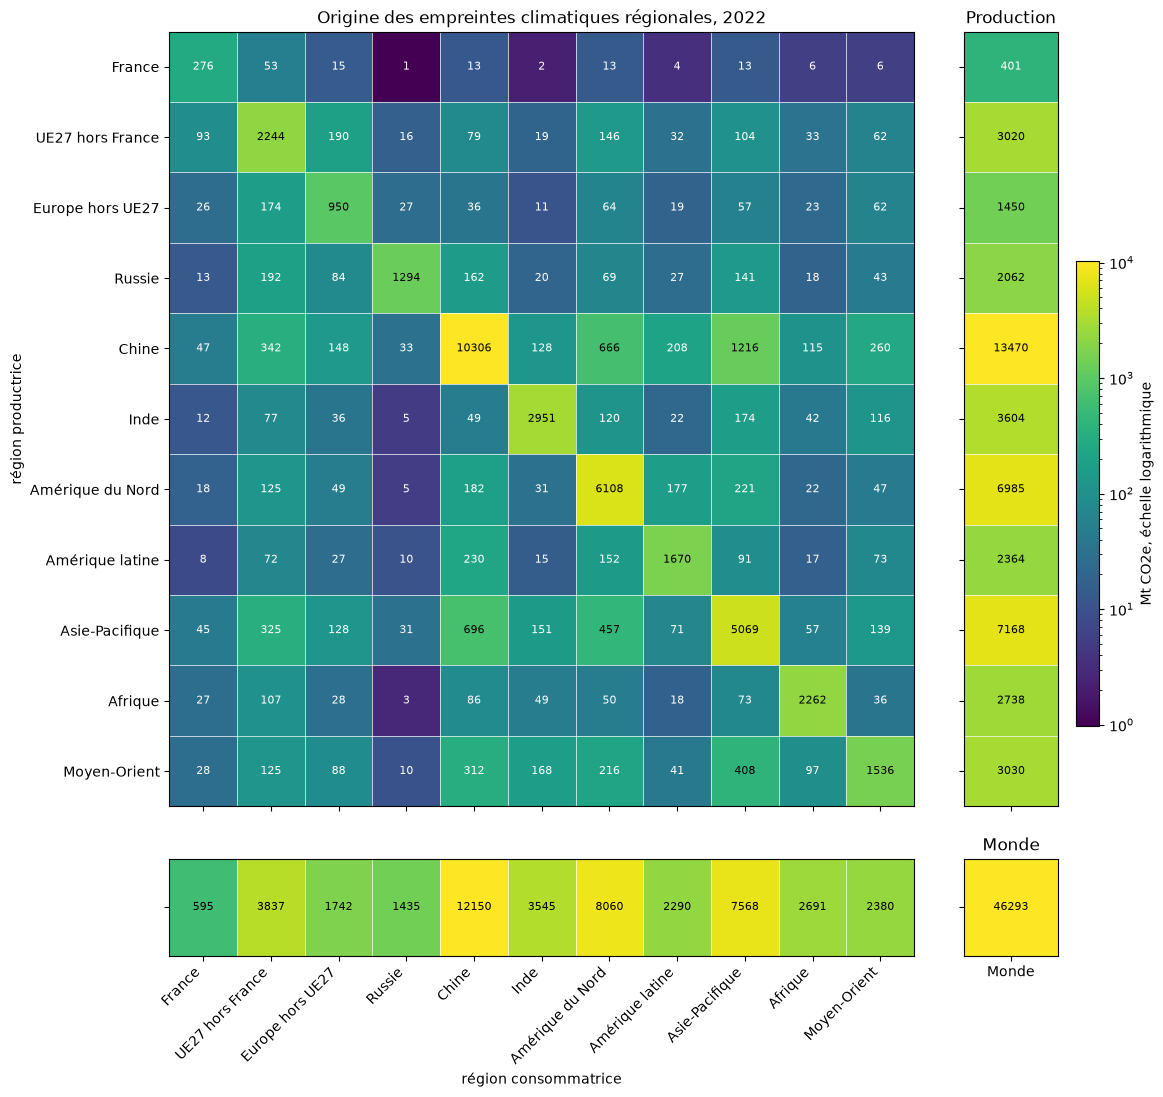

In [10]:
cmap = "viridis"
norme = LogNorm(
    vmin=max(0.05, flux_groupes.where(flux_groupes > 0).min().min()),
    vmax=flux_groupes.max().max(),
)

totaux_production = flux_groupes.sum(axis=1).to_frame("Total")
totaux_consommation = flux_groupes.sum(axis=0).to_frame().T
totaux_consommation.index = ["Total"]
total_mondial = pd.DataFrame(
    [[flux_groupes.to_numpy().sum()]], index=["Total"], columns=["Monde"]
)

fig, ax = plt.subplots(
    ncols=2,
    nrows=2,
    figsize=(12, 12),
    subplot_kw={"facecolor": "white"},
    gridspec_kw={
        "width_ratios": [8, 1],
        "height_ratios": [8, 1],
        "wspace": 0.12,
        "hspace": 0.12,
    },
    sharex="col",
)

def dessiner_carte(axe, donnees):
    image = axe.imshow(
        donnees.to_numpy(), cmap=cmap, norm=norme, aspect="auto"
    )
    axe.set_xticks(range(len(donnees.columns)), donnees.columns)
    axe.set_yticks(range(len(donnees.index)), donnees.index)
    axe.set_xticks(
        np.arange(-0.5, len(donnees.columns), 1), minor=True
    )
    axe.set_yticks(np.arange(-0.5, len(donnees.index), 1), minor=True)
    axe.grid(which="minor", color="white", linewidth=0.5)
    axe.tick_params(which="minor", bottom=False, left=False)

    for ligne in range(len(donnees.index)):
        for colonne in range(len(donnees.columns)):
            valeur = donnees.iat[ligne, colonne]
            couleur = "white" if norme(max(valeur, norme.vmin)) < 0.65 else "black"
            axe.text(
                colonne, ligne, f"{valeur:.0f}",
                ha="center", va="center", color=couleur, fontsize=8,
            )
    return image

image_principale = dessiner_carte(ax[0, 0], flux_groupes)
dessiner_carte(ax[0, 1], totaux_production)
dessiner_carte(ax[1, 0], totaux_consommation)
dessiner_carte(ax[1, 1], total_mondial)

ax[0, 0].set(
    title=f"Origine des empreintes climatiques régionales, {ANNEE}",
    xlabel="",
    ylabel="région productrice",
)
ax[0, 0].tick_params(axis="x", labelrotation=45)
for etiquette in ax[0, 0].get_xticklabels():
    etiquette.set_horizontalalignment("right")
ax[0, 1].set(xlabel="", ylabel="", title="Production")
ax[0, 1].set_yticklabels([])
ax[1, 0].set(xlabel="région consommatrice", ylabel="")
ax[1, 0].set_yticklabels([])
ax[1, 0].tick_params(axis="x", labelrotation=45)
for etiquette in ax[1, 0].get_xticklabels():
    etiquette.set_horizontalalignment("right")
ax[1, 1].set(xlabel="", ylabel="", title="Monde")
ax[1, 1].set_yticklabels([])

barre = fig.colorbar(
    image_principale, ax=ax.ravel().tolist(), fraction=0.025, pad=0.02
)
barre.set_label("Mt CO2e, échelle logarithmique")

## 7. Exemple d’analyse pour la France

La colonne `France` décompose l’empreinte française par région d’origine. La part importée correspond ici aux émissions situées hors de France.

In [11]:
origine_france = flux_groupes["France"].sort_values(ascending=False)
part_hors_france = 100 * (
    1 - origine_france.loc["France"] / origine_france.sum()
)

display(origine_france.rename("Mt CO2e").to_frame())
print(f"Part de l’empreinte située hors de France : {part_hors_france:.1f} %")

,Mt CO2e
région productrice,
France,276.466324
UE27 hors France,92.968388
Chine,47.443980
Asie-Pacifique,45.456209
Moyen-Orient,27.835079
Afrique,27.384978
Europe hors UE27,26.400976
Amérique du Nord,18.154454
Russie,12.985756


Part de l’empreinte située hors de France : 53.5 %


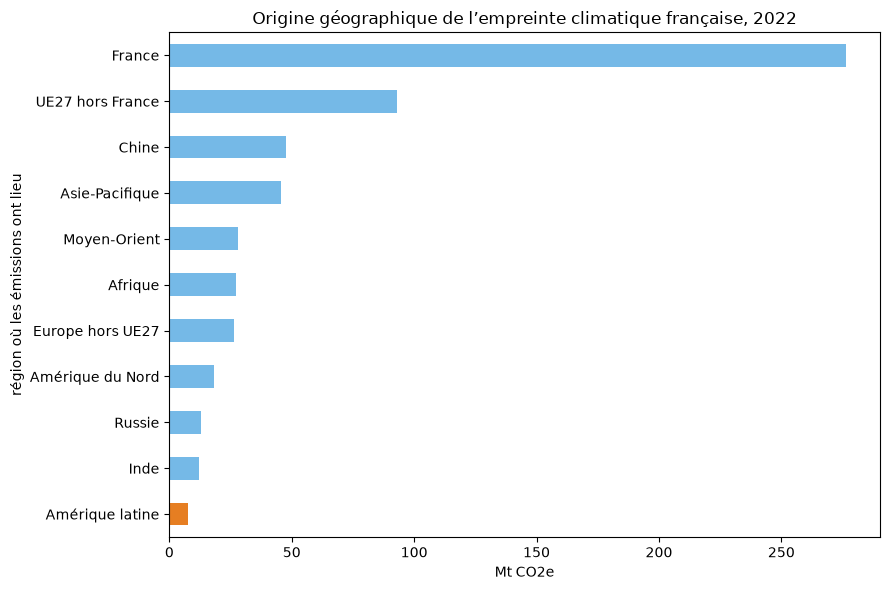

In [12]:
couleurs = [
    "#E67E22" if region == "France" else "#75B9E7"
    for region in origine_france.index
]
ax = origine_france.sort_values().plot.barh(figsize=(9, 6), color=couleurs)
ax.set(
    title=f"Origine géographique de l’empreinte climatique française, {ANNEE}",
    xlabel="Mt CO2e",
    ylabel="région où les émissions ont lieu",
)
plt.tight_layout()

## 8. Comparer les composantes internes et externes

Pour chaque groupe, la diagonale donne la composante interne et le reste de la colonne donne la composante externe. Attention : pour un groupe composé de plusieurs pays, la composante interne inclut les échanges entre ces pays. Elle ne signifie donc pas nécessairement production nationale.

In [13]:
composante_interne = pd.Series(
    np.diag(flux_groupes), index=ordre_groupes
)
empreinte_groupes = flux_groupes.sum(axis=0)
composition = pd.DataFrame(
    {
        "interne au groupe": composante_interne,
        "extérieur au groupe": empreinte_groupes - composante_interne,
    }
)
composition_pct = composition.div(empreinte_groupes, axis=0) * 100
composition_pct.sort_values("extérieur au groupe").round(1)

,interne au groupe,extérieur au groupe
Russie,90.1,9.9
Chine,84.8,15.2
Afrique,84.0,16.0
Inde,83.2,16.8
Amérique du Nord,75.8,24.2
Amérique latine,72.9,27.1
Asie-Pacifique,67.0,33.0
Moyen-Orient,64.5,35.5
UE27 hors France,58.5,41.5
Europe hors UE27,54.5,45.5


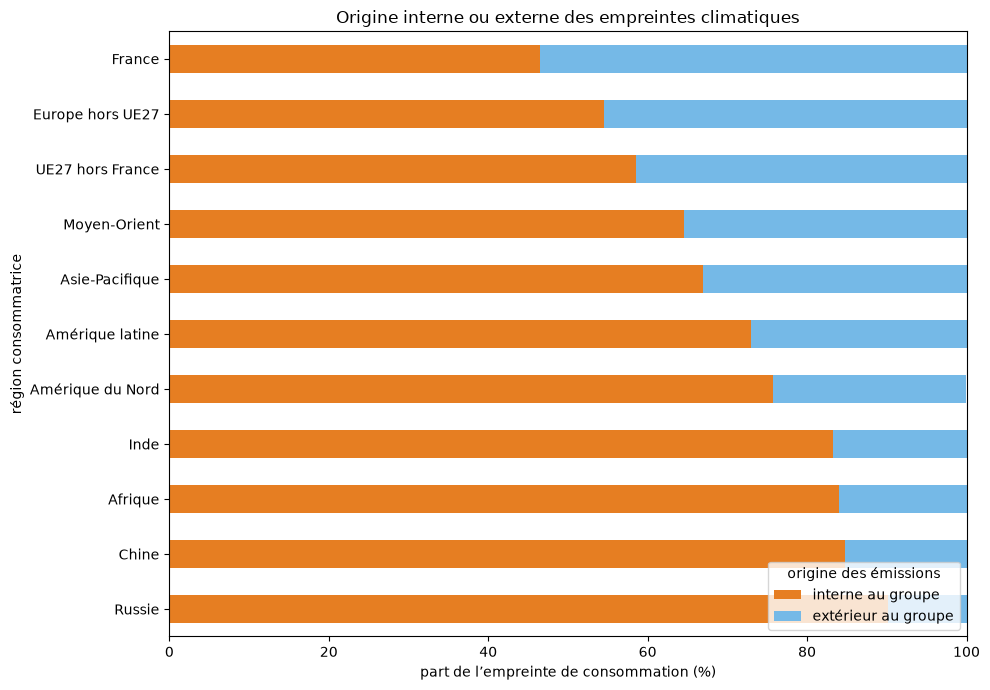

In [14]:
ax = composition_pct.sort_values("extérieur au groupe").plot.barh(
    stacked=True, figsize=(10, 7), color=["#E67E22", "#75B9E7"]
)
ax.set(
    title="Origine interne ou externe des empreintes climatiques",
    xlabel="part de l’empreinte de consommation (%)",
    ylabel="région consommatrice",
    xlim=(0, 100),
)
ax.legend(title="origine des émissions", loc="lower right")
plt.tight_layout()

## 9. Importations, exportations et solde incorporé

Pour un groupe donné, les importations incorporées sont la somme de sa colonne hors diagonale. Les exportations incorporées sont la somme de sa ligne hors diagonale. Un solde positif signifie que le groupe importe davantage d’émissions incorporées qu’il n’en exporte.

In [15]:
importations_incorporees = flux_groupes.sum(axis=0) - composante_interne
exportations_incorporees = flux_groupes.sum(axis=1) - composante_interne
soldes = pd.DataFrame(
    {
        "importations incorporées": importations_incorporees,
        "exportations incorporées": exportations_incorporees,
        "solde importateur": importations_incorporees - exportations_incorporees,
    }
).sort_values("solde importateur", ascending=False)
soldes.round(1)

,importations incorporées,exportations incorporées,solde importateur
Amérique du Nord,1951.9,877.1,1074.8
UE27 hors France,1592.2,775.5,816.7
Asie-Pacifique,2499.2,2099.4,399.8
Europe hors UE27,792.0,500.2,291.7
France,318.3,124.7,193.6
Afrique,429.4,476.4,-47.0
Inde,593.9,653.6,-59.7
Amérique latine,619.6,694.0,-74.4
Russie,141.5,768.4,-626.9
Moyen-Orient,844.0,1493.2,-649.2


## 10. Deux opérations à ne pas confondre

| Opération | Ordre du calcul | Conséquence |
|---|---|---|
| **Agrégation des comptes environnementaux** | Calculer les comptes avec les 49 régions, puis additionner leurs résultats | Le total est conservé exactement et les technologies détaillées restent représentées |
| **Comptes environnementaux de la table agrégée** | Agréger $Z$, $Y$, $F$ et les autres données, puis recalculer $A$, $L$, $S$ et les comptes | Les technologies sont moyennées à l’intérieur des groupes et les résultats peuvent changer |

Dans ce notebook, nous réalisons la première opération : les comptes sont calculés à pleine résolution avant d’être agrégés.

La méthode `io.aggregate()` de PyMRIO permet de réaliser la seconde. Elle réduit la taille du modèle, mais son résultat ne doit pas être présenté comme une simple mise en forme des comptes détaillés. Pour comparer les deux méthodes, il faut utiliser la même concordance et mesurer explicitement les écarts.

## 11. Questions pour guider l’interprétation

1. Quelles régions expliquent l’essentiel de la composante importée de l’empreinte française ?
2. La région ayant la plus grande empreinte est-elle aussi celle dont la production émet le plus ?
3. Que devient la lecture de la diagonale si la France est intégrée au groupe UE27 ?
4. Quels choix de regroupement seraient plus adaptés à une analyse de l’eau ou des matières ?
5. Pourquoi faut-il conserver la table de concordance avec les résultats présentés dans un poster ?

## À retenir

- une matrice origine-destination relie le lieu des pressions au lieu de la demande finale ;
- les colonnes décrivent les empreintes de consommation et les lignes les émissions attribuables à la production ;
- une concordance doit être explicite, complète et adaptée à la question étudiée ;
- la diagonale signifie interne au groupe, pas nécessairement national ;
- agréger des comptes déjà calculés et recalculer les comptes d’une table agrégée sont deux opérations différentes ;
- une agrégation facilite la lecture, mais masque les différences entre les éléments regroupés ;
- toute agrégation doit conserver les totaux et faire l’objet d’un contrôle numérique.